In [1]:
#Install pyspark
!pip install pyspark

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
#Start sparksession
spark = (SparkSession.builder
         .appName("MovieLens_Analysis")
         .getOrCreate())
print("Spark Session Created")

Spark Session Created


In [8]:
#Download the datasets derectly
!wget https://files.grouplens.org/datasets/movielens/ml-25m.zip


--2026-05-15 16:57:16--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip’

ml-25m.zip          100%[===================>] 249.84M  52.9MB/s    in 4.9s    

2026-05-15 16:57:21 (50.7 MB/s) - ‘ml-25m.zip’ saved [261978986/261978986]



In [9]:
#Unzip the file
!unzip ml-25m.zip

Archive:  ml-25m.zip
   creating: ml-25m/
  inflating: ml-25m/tags.csv         
  inflating: ml-25m/links.csv        
  inflating: ml-25m/README.txt       
  inflating: ml-25m/ratings.csv      
  inflating: ml-25m/genome-tags.csv  
  inflating: ml-25m/genome-scores.csv  
  inflating: ml-25m/movies.csv       


In [13]:
#Read the movie data
movies_df =  spark.read.csv('ml-25m/movies.csv', header=True, inferSchema=True)

In [14]:
#Read rating data
ratings_df = spark.read.csv('ml-25m/ratings.csv', header=True, inferSchema=True)

In [15]:
print("Movies Data Sample:")
movies_df.show(5)

Movies Data Sample:
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [16]:
print("Ratings Data Sample:")
ratings_df.show(5)

Ratings Data Sample:
+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|    296|   5.0|1147880044|
|     1|    306|   3.5|1147868817|
|     1|    307|   5.0|1147868828|
|     1|    665|   5.0|1147878820|
|     1|    899|   3.5|1147868510|
+------+-------+------+----------+
only showing top 5 rows


In [18]:
#Calculate avg ratings according to movie id
movies_ratings = ratings_df.groupBy("movieId").agg(F.avg("rating").alias("avg_rating"),
                                                   F.count("rating").alias("total_ratings"))

In [30]:
#Join rating data with movie name
top_movies = movies_ratings.join(movies_df, "movieId")

In [36]:
#Extract top ten such movies which has atleast 500 ratings
final_top_ten = (top_movies
                 .filter("total_ratings > 500")
                 .orderBy(F.desc("avg_rating"))
                 .select("title", "avg_rating", "total_ratings")
                 .limit(10))

print("Top ten movies which have more than 500 reviews:")
final_top_ten.show()

Top ten movies which have more than 500 reviews:
+--------------------+------------------+-------------+
|               title|        avg_rating|total_ratings|
+--------------------+------------------+-------------+
|Planet Earth II (...| 4.483096085409253|         1124|
| Planet Earth (2006)| 4.464796794504865|         1747|
|Shawshank Redempt...| 4.413576004516335|        81482|
|Band of Brothers ...| 4.398598820058997|         1356|
|Godfather, The (1...| 4.324336165187245|        52498|
|Blue Planet II (2...| 4.289833080424886|          659|
|Usual Suspects, T...| 4.284353213163313|        55366|
|Godfather: Part I...|4.2617585117585115|        34188|
|Over the Garden W...| 4.258241758241758|          546|
|Seven Samurai (Sh...|  4.25476920775043|        13367|
+--------------------+------------------+-------------+



In [39]:
import matplotlib.pyplot as plt
import pandas as pd
#Convert spark dataframe to pandas dataframe
pdf = final_top_ten.limit(10).toPandas()

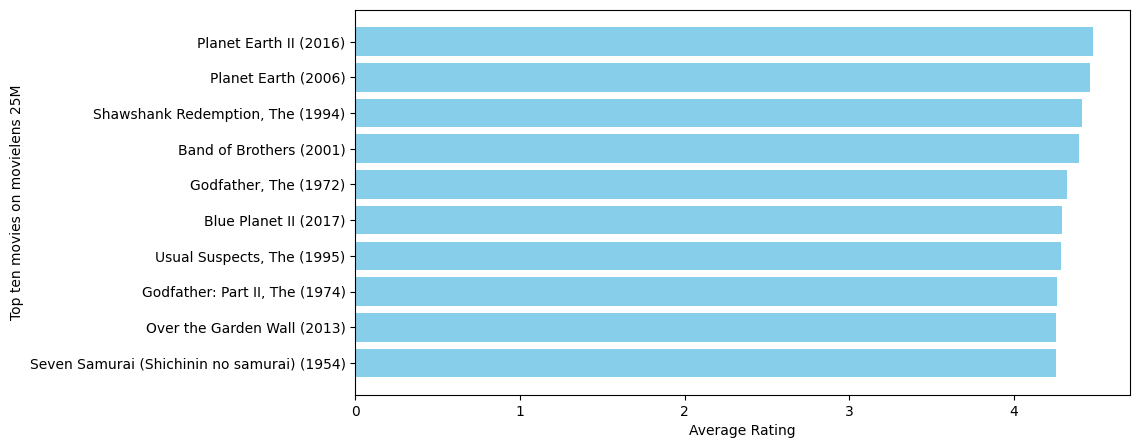

In [40]:
plt.figure(figsize=(10,5))
plt.barh(pdf['title'],pdf['avg_rating'],color='skyblue')
plt.xlabel('Average Rating')
plt.ylabel('Top ten movies on movielens 25M')
plt.gca().invert_yaxis()
plt.show()

In [41]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col,explode

In [42]:
(training_data, test_data) = ratings_df.randomSplit([0.8,0.2], seed=42)

In [43]:
print(f"Total Data Count:{ratings_df.count()}")
print(f"Traning Data Count:{training_data.count()}")
print(f"Test Data Count:{test_data.count()}")

Total Data Count:25000095
Traning Data Count:19999121
Test Data Count:5000974


In [48]:
#ALS model setup
als = ALS(maxIter=5, #how maany times model visit over the data
          regParam=0.01,
          userCol="userId",
          itemCol="movieId",
          coldStartStrategy="drop")#Ensure that no errors occur when a new user joins
print("Model training is starting.....(It might take some time)")
#Fit the model
model = als.fit(training_data)
print("Completed")


Model training is starting.....(It might take some time)
Completed


In [49]:
#Prediction on testing data
predictions = model.transform(test_data)

In [51]:
#Evaluator setup
evaluator = RegressionEvaluator(metricName="rmse",
                                labelCol="rating",
                                predictionCol="prediction")

In [52]:
#Calculate error
rmse = evaluator.evaluate(predictions)
print(f"Root-mean-square error (RMSE) = {rmse:.4f}")

Root-mean-square error (RMSE) = 0.8108


In [53]:
#Pick one's user id from from testing
sample_user = test_data.select("userId").limit(1)
sample_user_id = sample_user.first()[0]
print(f"User id: making a recommedation for {sample_user_id}")

User id: making a recommedation for 1


In [54]:
#Recommed 5 movies for this user
user_recs = model.recommendForUserSubset(sample_user,5)

In [63]:
user_recs_explode = user_recs.withColumn("rec",explode("recommendations")).select(col("userId"),col("rec.movieId"),col("rec.rating").alias("predicted_rating"))

In [69]:
final_recommendations = (user_recs_explode
                         .join(movies_df, "movieId")
                         .select("title", "genres", "predicted_rating")
                         .orderBy(col("predicted_rating").desc()))



In [70]:
#Show result
print("Top 5 movies by model:")
final_recommendations.show(truncate=False)

Top 5 movies by model:
+-------------------------------------------+----------------------+----------------+
|title                                      |genres                |predicted_rating|
+-------------------------------------------+----------------------+----------------+
|War-Time Romance (1983)                    |(no genres listed)    |12.009171       |
|The Lion of Thebes (1964)                  |Action|Adventure|Drama|11.058289       |
|Cook-Off! (2017)                           |Comedy                |10.604605       |
|Lezione ventuno (2008)                     |(no genres listed)    |10.12159        |
|Key of Life (Kagi-dorobô no mesoddo) (2012)|Comedy|Crime|Romance  |9.415663        |
+-------------------------------------------+----------------------+----------------+

